In [26]:
import os
import numpy as np
import pandas as pd
import seaborn as sb
import pickle
import matplotlib.pyplot as plt
import PcmPy as pcm
import EFC_learningfMRI.globals as gl
import EFC_learningfMRI.pcm as pcm_
import EFC_learningfMRI.vis as vis
import EFC_learningfMRI.util as util
from EFC_learningfMRI.G_matrix import G_sorted

In [27]:
H     = 'L'
atlas = 'ROI'
rois  = gl.rois[atlas]
glm   = 3
sns   = gl.participants
                       # the shade pcm.model_plot uses for the band

# Component model

Components and corresponding hypothesis about representational geometry:

- **type**     : trained vs. untrained, geometry reflects which chords are practiced
- **trained**  : trained chords are equally distant among each other, no distance between untrained (larger weight -> more pattern separation among *trained* chords)
- **untrained**: untrained chords are equally distant among each other, no distance between untrained (larger weight -> more pattern separation among *untrained* chords)
- **finger**   : geometry reflects which fingers are used in each chord
- **pattern**  : geometry reflects which fingers are used in each chord, and in what direction (i.e., flexion or extension)
- **flexion**  : geometry reflects how many fingers in each chord are pressed in flexion direction
- **force_raw**: geometry reflects the *signed* force the participant actually produced, so chords that use the same fingers in opposite directions are far apart
- **force_abs**: geometry reflects the *absolute* force actually produced, i.e. which fingers were pressed and how hard, with flexion and extension collapsed onto each other
- **force_der**: geometry reflects the *absolute derivative* of the force actually produced, i.e. how fast each finger changed force

*The **finger**, **pattern** and **flexion** components are different in each participant, depending on the assigned trained and untrained chords 

*The **force_raw**, **force_abs** and **force_der** components are the average second-moment matrices of the 5-finger force in session 3, so they ask how much of the neural geometry is already accounted for by the force geometry. 

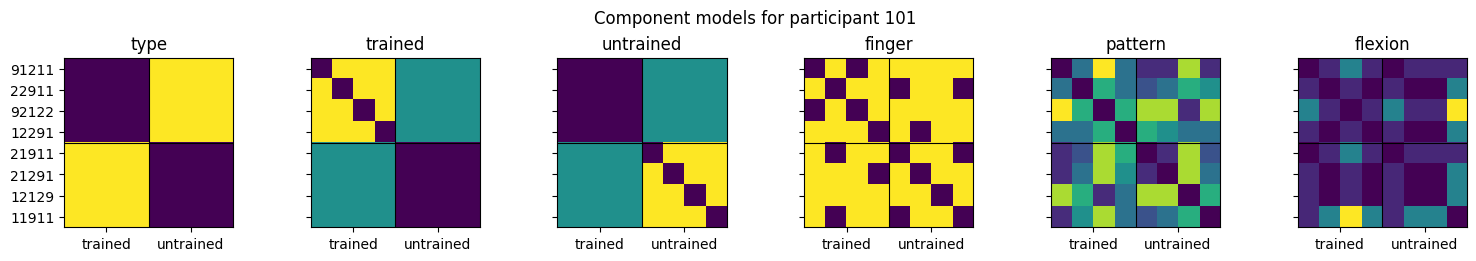

In [28]:
sn = 101
M, comp_names = pcm_.make_models(sn)
Mc = M[-2]

trained_untrained = pcm_.get_trained_and_untrained(sn)

fig, axs = plt.subplots(1, Mc.Gc.shape[0], sharex=True, sharey=True, figsize=(15, 2.5), constrained_layout=True)

for i, G in enumerate(Mc.Gc):
    ax = axs[i]
    d = pcm.G_to_dist(G)
    ax.imshow(d)
    ax.axhline(3.5, lw=.8, color='k')
    ax.axvline(3.5, lw=.8, color='k')
    ax.set_xticks([1.5, 5.5])
    ax.set_xticklabels(['trained', 'untrained'])
    ax.set_yticks(np.arange(8))
    ax.set_yticklabels(trained_untrained)
    ax.set_title(comp_names[i])

fig.suptitle(f'Component models for participant {sn}')

fig.savefig('figures/components.pdf')

plt.show()

## Neural dissimilarities in session 3

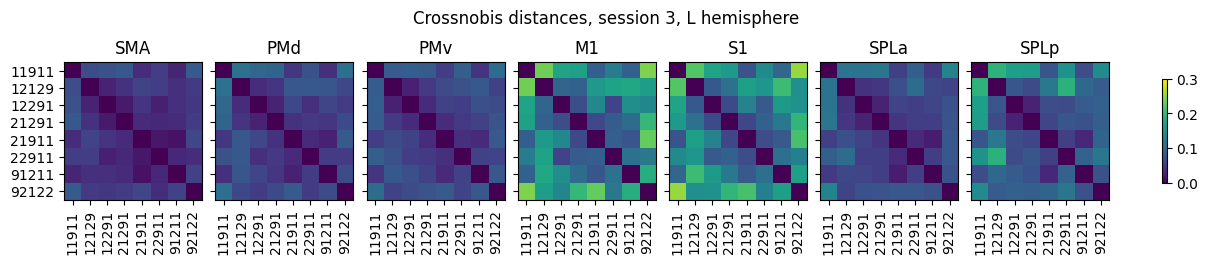

In [29]:
session = 3

D = np.zeros((len(sns), len(rois), len(gl.chordID), len(gl.chordID)))

for s, sn in enumerate(sns):
    for r, roi in enumerate(rois):
        fname = f'G_obs_raw.within_session.{session}.glm{glm}.{H}.{roi}.npy'
        G     = np.load(os.path.join(gl.baseDir, gl.pcmDir, f'subj{sn}', fname))
        G     = G_sorted(G, sn, order=gl.chordID)     # stored trained-first, put on a common chord order
        D[s, r] = pcm.G_to_dist(G)                    # crossnobis distances

fig, axs = plt.subplots(1, len(rois), figsize=(12, 2.5), constrained_layout=True, sharex=True, sharey=True)

vmin, vmax = 0, .3

for r, roi in enumerate(rois):
    ax = axs[r]
    im = ax.imshow(D[:, r].mean(axis=0), vmin=vmin, vmax=vmax, cmap='viridis')
    ax.set_xticks(np.arange(8))
    ax.set_xticklabels(gl.chordID, rotation=90)
    ax.set_yticks(np.arange(8))
    ax.set_yticklabels(gl.chordID)
    ax.set_title(roi)

fig.colorbar(im, ax=axs, fraction=.005)

fig.suptitle(f'Crossnobis distances, session {session}, {H} hemisphere')

plt.show()

## Force dissimilarities in session 3

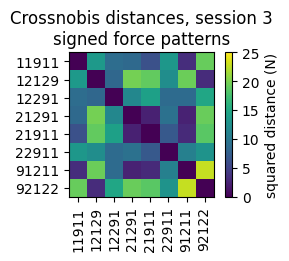

In [30]:
D = np.zeros((len(sns), len(gl.chordID), len(gl.chordID)))

for s, sn in enumerate(sns):
    fname = f'G_obs_raw.within_session.{session}.force.raw.npy'
    G     = np.load(os.path.join(gl.baseDir, gl.pcmDir, f'subj{sn}', fname))
    G     = G_sorted(G, sn, order=gl.chordID)   # stored trained-first, put on a common chord order
    D[s]  = pcm.G_to_dist(G)                    # crossnobis distances

fig, ax = plt.subplots(figsize=(3, 2.5), constrained_layout=True, sharex=True, sharey=True)

vmin, vmax = 0, 25

im = ax.imshow(D.mean(axis=0), vmin=vmin, vmax=vmax, cmap='viridis')
ax.set_xticks(np.arange(8))
ax.set_xticklabels(gl.chordID, rotation=90)
ax.set_yticks(np.arange(8))
ax.set_yticklabels(gl.chordID)

fig.colorbar(im, ax=ax, fraction=.05, label='squared distance (N)')

ax.set_title(f'Crossnobis distances, session {session}\nsigned force patterns')

plt.show()

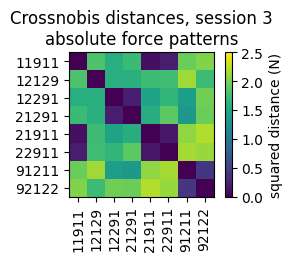

In [31]:
D = np.zeros((len(sns), len(gl.chordID), len(gl.chordID)))

for s, sn in enumerate(sns):
    fname = f'G_obs_raw.within_session.{session}.force.abs.npy'
    G     = np.load(os.path.join(gl.baseDir, gl.pcmDir, f'subj{sn}', fname))
    G     = G_sorted(G, sn, order=gl.chordID)     # stored trained-first, put on a common chord order
    D[s] = pcm.G_to_dist(G)                    # crossnobis distances

fig, ax = plt.subplots(figsize=(3, 2.5), constrained_layout=True, sharex=True, sharey=True)

vmin, vmax = 0, 2.5

im = ax.imshow(D.mean(axis=0), vmin=vmin, vmax=vmax, cmap='viridis')
ax.set_xticks(np.arange(8))
ax.set_xticklabels(gl.chordID, rotation=90)
ax.set_yticks(np.arange(8))
ax.set_yticklabels(gl.chordID)

fig.colorbar(im, ax=ax, fraction=.05, label='squared distance (N)')

ax.set_title(f'Crossnobis distances, session {session}\nabsolute force patterns')

plt.show()

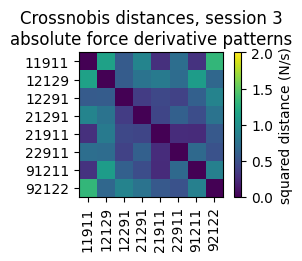

In [32]:
D = np.zeros((len(sns), len(gl.chordID), len(gl.chordID)))

for s, sn in enumerate(sns):
    fname = f'G_obs_raw.within_session.{session}.force.der.npy'
    G     = np.load(os.path.join(gl.baseDir, gl.pcmDir, f'subj{sn}', fname))
    G     = G_sorted(G, sn, order=gl.chordID)     # stored trained-first, put on a common chord order
    D[s] = pcm.G_to_dist(G)                    # crossnobis distances

fig, ax = plt.subplots(figsize=(3, 2.5), constrained_layout=True, sharex=True, sharey=True)

vmin, vmax = 0, 2

im = ax.imshow(D.mean(axis=0), vmin=vmin, vmax=vmax, cmap='viridis')
ax.set_xticks(np.arange(8))
ax.set_xticklabels(gl.chordID, rotation=90)
ax.set_yticks(np.arange(8))
ax.set_yticklabels(gl.chordID)

fig.colorbar(im, ax=ax, fraction=.05, label='squared distance (N/s)')

ax.set_title(f'Crossnobis distances, session {session}\nabsolute force derivative patterns')

plt.show()

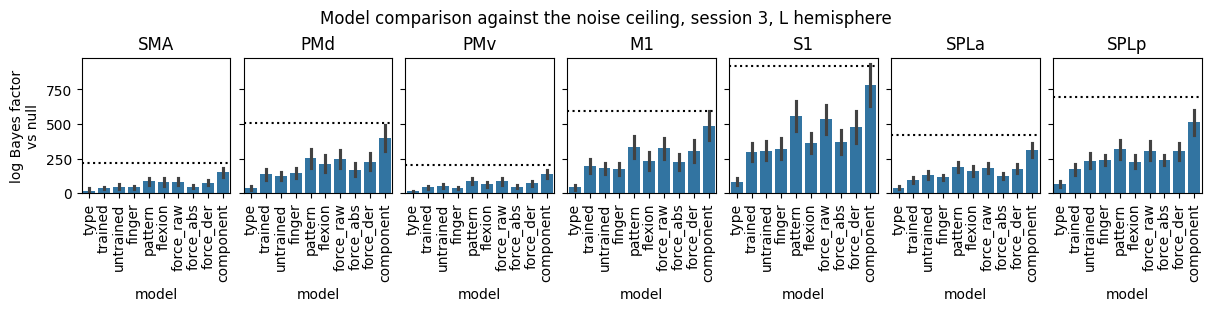

In [33]:
LL = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'likelihood.{atlas}.glm{glm}.tsv'), sep='\t')
LL = LL.rename_axis(columns='model')              # model_plot melts on the columns name, which read_csv drops
LL = LL[LL.Hem == H]

fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(12, 3), constrained_layout=True)

for r, roi in enumerate(rois):
    ax = axs[r]
    plt.sca(ax)                                   # model_plot draws on the current axes

    ll = LL[(LL.roi == roi) & (LL.session == session)].drop(columns=['sn', 'session', 'Hem', 'roi'])
    pcm.model_plot(ll, null_model='null', noise_ceiling='ceil', errorbar='se', noise_ceil_col='k')

    ax.tick_params(axis='x', labelrotation=90)    # set_xticks would drop the model names
    ax.set_ylabel('log Bayes factor\nvs null' if r == 0 else None)
    ax.set_title(roi)

fig.suptitle(f'Model comparison against the noise ceiling, session {session}, {H} hemisphere')

plt.show()

           T  dof     p_val           CI95   roi  session
0  -1.507828   15  0.152370  [-0.04, 0.01]   SMA        3
1  -0.698422   15  0.495600  [-0.04, 0.02]   SMA        9
2   0.404466   15  0.691578  [-0.02, 0.03]   SMA       23
3  -0.901716   15  0.381459  [-0.04, 0.02]   PMd        3
4  -1.597702   15  0.130957  [-0.08, 0.01]   PMd        9
5   0.696474   15  0.496784  [-0.02, 0.03]   PMd       23
6  -0.198334   15  0.845447  [-0.04, 0.04]   PMv        3
7  -0.833171   15  0.417818  [-0.06, 0.02]   PMv        9
8   0.046334   15  0.963655  [-0.02, 0.02]   PMv       23
9  -1.050571   15  0.310088   [-0.1, 0.04]    M1        3
10 -0.075685   15  0.940670  [-0.05, 0.04]    M1        9
11  2.161565   15  0.047227    [0.0, 0.12]    M1       23
12 -1.000720   15  0.332833  [-0.06, 0.02]    S1        3
13  0.289473   15  0.776182  [-0.04, 0.06]    S1        9
14  2.651036   15  0.018154    [0.01, 0.1]    S1       23
15 -1.409929   15  0.178958  [-0.07, 0.01]  SPLa        3
16 -1.054040  

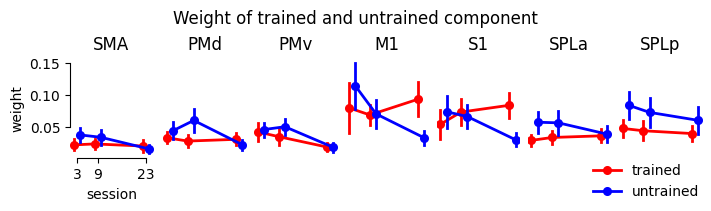

In [34]:
comp_model = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'component_model.{atlas}.glm{glm}.tsv'), sep='\t')
N = comp_model.sn.nunique()
hue_order, palette = (['trained', 'untrained'], ['red', 'blue'])
comp_model_tr_untr = comp_model[comp_model.component.isin(hue_order) & (comp_model.Hem==H)]

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

vis.plot_im_sess(fig, axs, comp_model_tr_untr, rois, y='weight', x='session', hue='component', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.3)

sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('weight')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Weight of trained and untrained component')

ttest = util.ttest_im_sess(comp_model_tr_untr, rois, y='weight', x='session', hue='component', hue_order=hue_order)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

fig.savefig('figures/component_model_trained_untrained.pdf')

plt.show()

/localscratch/tmp/ipykernel_605920/1785719960.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(frameon=False, loc='lower right')


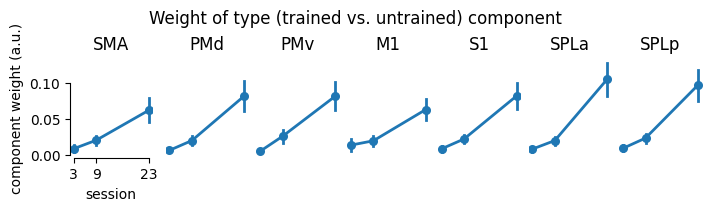

In [35]:
comp_model_repr = comp_model[comp_model.component=='type']

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

vis.plot_im_sess(fig, axs, comp_model_repr, rois, y='weight', x='session', kind='point', dodge=.3, estimator='mean')

sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('component weight (a.u.)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Weight of type (trained vs. untrained) component')

fig.savefig('figures/component_model_pattern_flexion.pdf')

plt.show()

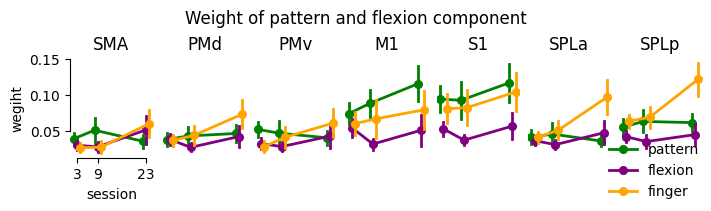

In [36]:
hue_order, palette = ['pattern', 'flexion', 'finger'], ['green', 'purple','orange']
comp_model_repr = comp_model[comp_model.component.isin(hue_order)]

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

vis.plot_im_sess(fig, axs, comp_model_repr, rois, y='weight', x='session', hue='component', hue_order=hue_order, palette=palette, kind='point', dodge=.3, estimator='mean')
#plot_im_sess(fig, axs, comp_model_repr, rois, y='weight_norm', x='session', hue='component', hue_order=hue_order, palette=palette, kind='strip', jitter=.2, alpha=.2)

sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('wegiht')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Weight of pattern and flexion component')

fig.savefig('figures/component_model_pattern_flexion.pdf')

plt.show()